# ATDL Assignment 1 — Task 3: Joint KD + QAT Training of the Ternary Student

**Goal (per the assignment):** train the ternary ResNet18 student using Knowledge Distillation from the frozen ResNet34 teacher, combined with Quantization-Aware Training, so the ternary constraint is respected throughout training (not applied post-hoc).

**Self-contained by design:** the teacher architecture (Task 1) and ternary student architecture (Task 2) are both re-defined directly in this notebook, rather than imported from the other notebooks. This means this notebook only needs the two **checkpoint files** already sitting in `atdl/` — it survives a fresh Colab session with nothing else uploaded. Keep the Task 2 notebook as its own file for your submitted repo (it's the documented deliverable) — if you ever change the quantizer logic there, mirror the change here too, since this copy is now independent.

**Requires in `atdl/` already:**
- `resnet34_cifar10_teacher_best.pth` (Task 1)
- `resnet18_cifar10_fp32_baseline_best.pth` (Task 4 baseline — used as the student's warm-start init)

**Required reading this ties to:** Hinton, Vinyals, Dean, *Distilling the Knowledge in a Neural Network* — the temperature-scaled soft-target loss implemented below.

**What this notebook does:**
1. Load the frozen teacher and warm-start the student from the FP32 baseline.
2. Train with the combined KD + hard-label loss, with **every student forward pass going through the ternary quantizer** — no "train FP32 then quantize after" shortcut anywhere.
3. Save the best checkpoint, verify the ternary constraint on it, and report an honest train/test gap.
4. (Separate, optional section at the end) run the required ablation sweep over temperature or alpha.

**Before running:** Runtime > Change runtime type > T4 GPU.

In [1]:
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_DIR = "/content/drive/MyDrive/atdl"
    os.makedirs(DRIVE_DIR, exist_ok=True)
else:
    DRIVE_DIR = "."

TEACHER_CKPT = os.path.join(DRIVE_DIR, "resnet34_cifar10_teacher_best.pth")
BASELINE_CKPT = os.path.join(DRIVE_DIR, "resnet18_cifar10_fp32_baseline_best.pth")
STUDENT_CKPT = os.path.join(DRIVE_DIR, "ternary_resnet18_kd_qat_student_best.pth")
CURVE_PATH = os.path.join(DRIVE_DIR, "student_training_curves.png")

for name, path in [("Teacher", TEACHER_CKPT), ("Baseline", BASELINE_CKPT)]:
    status = "found" if os.path.exists(path) else "MISSING -- run that notebook first!"
    print(f"{name} checkpoint ({path}): {status}")

Mounted at /content/drive
Teacher checkpoint (/content/drive/MyDrive/atdl/resnet34_cifar10_teacher_best.pth): found
Baseline checkpoint (/content/drive/MyDrive/atdl/resnet18_cifar10_fp32_baseline_best.pth): found


In [2]:
import copy
import json
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset
from torch.amp import autocast, GradScaler
import matplotlib.pyplot as plt

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type != "cuda":
    print("WARNING: no GPU detected. Go to Runtime > Change runtime type > T4 GPU.")

Using device: cuda


## Embedded: ResNet34 teacher architecture

Identical to the Task 1 notebook -- needed here only to instantiate the model shape before loading its trained weights. This model will be frozen immediately after loading and never receive a gradient again.

In [3]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride,
                                padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1,
                                padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class ResNetCIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)


def ResNet34(num_classes=10):
    return ResNetCIFAR(BasicBlock, [3, 4, 6, 3], num_classes)

## Embedded: ternary quantizer + `TernaryResNet18`

Identical to the Task 2 notebook -- the quantizer, STE, ternary layers, full student, and verification/loading utilities.

In [4]:
def ternary_quantize(w, per_channel=True, delta_factor=0.7):
    orig_shape = w.shape
    if per_channel:
        w_flat = w.reshape(w.size(0), -1)
        delta = delta_factor * w_flat.abs().mean(dim=1, keepdim=True)
        mask = (w_flat.abs() > delta).float()
        denom = mask.sum(dim=1, keepdim=True).clamp(min=1.0)
        alpha = (w_flat.abs() * mask).sum(dim=1, keepdim=True) / denom
        w_q = (alpha * mask * torch.sign(w_flat)).reshape(orig_shape)
        return w_q, alpha.view(-1), delta.view(-1)
    else:
        delta = delta_factor * w.abs().mean()
        mask = (w.abs() > delta).float()
        denom = mask.sum().clamp(min=1.0)
        alpha = (w.abs() * mask).sum() / denom
        w_q = alpha * mask * torch.sign(w)
        return w_q, alpha, delta


class _TernarySTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, w, delta_factor, per_channel, clip_grad, clip_value):
        w_q, _, _ = ternary_quantize(w, per_channel=per_channel, delta_factor=delta_factor)
        ctx.clip_grad = clip_grad
        if clip_grad:
            ctx.save_for_backward(w)
            ctx.clip_value = clip_value
        return w_q

    @staticmethod
    def backward(ctx, grad_output):
        if ctx.clip_grad:
            (w,) = ctx.saved_tensors
            grad_input = grad_output.clone()
            grad_input[w.abs() > ctx.clip_value] = 0.0
        else:
            grad_input = grad_output
        return grad_input, None, None, None, None


def ternary_quantize_ste(w, delta_factor=0.7, per_channel=True, clip_grad=False, clip_value=1.0):
    return _TernarySTE.apply(w, delta_factor, per_channel, clip_grad, clip_value)


class TernaryConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0,
                 bias=False, delta_factor=0.7, per_channel=True,
                 clip_grad=False, clip_value=1.0):
        super().__init__()
        self.weight = nn.Parameter(
            torch.empty(out_channels, in_channels, kernel_size, kernel_size))
        nn.init.kaiming_normal_(self.weight, mode="fan_out", nonlinearity="relu")
        self.bias = nn.Parameter(torch.zeros(out_channels)) if bias else None
        self.stride = stride
        self.padding = padding
        self.delta_factor = delta_factor
        self.per_channel = per_channel
        self.clip_grad = clip_grad
        self.clip_value = clip_value

    def forward(self, x):
        w_q = ternary_quantize_ste(self.weight, self.delta_factor, self.per_channel,
                                    self.clip_grad, self.clip_value)
        return F.conv2d(x, w_q, self.bias, stride=self.stride, padding=self.padding)


class TernaryLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True, delta_factor=0.7,
                 per_channel=True, clip_grad=False, clip_value=1.0):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5 ** 0.5)
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.delta_factor = delta_factor
        self.per_channel = per_channel
        self.clip_grad = clip_grad
        self.clip_value = clip_value

    def forward(self, x):
        w_q = ternary_quantize_ste(self.weight, self.delta_factor, self.per_channel,
                                    self.clip_grad, self.clip_value)
        return F.linear(x, w_q, self.bias)


class TernaryBasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, ternary_kwargs=None):
        super().__init__()
        tk = ternary_kwargs or {}
        self.conv1 = TernaryConv2d(in_planes, planes, kernel_size=3, stride=stride,
                                    padding=1, bias=False, **tk)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = TernaryConv2d(planes, planes, kernel_size=3, stride=1,
                                    padding=1, bias=False, **tk)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                TernaryConv2d(in_planes, self.expansion * planes, kernel_size=1,
                              stride=stride, bias=False, **tk),
                nn.BatchNorm2d(self.expansion * planes),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class TernaryResNetCIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, ternary_kwargs=None,
                 ternary_fc=False):
        super().__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], 1, ternary_kwargs)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], 2, ternary_kwargs)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], 2, ternary_kwargs)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], 2, ternary_kwargs)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        if ternary_fc:
            self.fc = TernaryLinear(512 * block.expansion, num_classes,
                                     **(ternary_kwargs or {}))
        else:
            self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride, ternary_kwargs):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s, ternary_kwargs=ternary_kwargs))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)


def TernaryResNet18(num_classes=10, delta_factor=0.7, per_channel=True,
                     clip_grad=False, clip_value=1.0, ternary_fc=False):
    ternary_kwargs = dict(delta_factor=delta_factor, per_channel=per_channel,
                           clip_grad=clip_grad, clip_value=clip_value)
    return TernaryResNetCIFAR(TernaryBasicBlock, [2, 2, 2, 2], num_classes,
                               ternary_kwargs=ternary_kwargs, ternary_fc=ternary_fc)


def load_fp32_init(ternary_model, fp32_state_dict, strict=True):
    missing, unexpected = ternary_model.load_state_dict(fp32_state_dict, strict=False)
    if strict and (missing or unexpected):
        raise RuntimeError(
            f"Checkpoint does not match student architecture.\n"
            f"Missing keys: {missing}\nUnexpected keys: {unexpected}"
        )
    return missing, unexpected


def verify_ternary_constraint(model, tol=1e-5):
    results = {}
    all_ok = True
    for name, module in model.named_modules():
        if isinstance(module, (TernaryConv2d, TernaryLinear)):
            w = module.weight.detach()
            w_q, alpha, delta = ternary_quantize(w, per_channel=module.per_channel,
                                                  delta_factor=module.delta_factor)
            if module.per_channel:
                w_q_flat = w_q.reshape(w_q.size(0), -1)
                ok = True
                for c in range(w_q_flat.size(0)):
                    vals = torch.unique(w_q_flat[c])
                    for v in vals.tolist():
                        if abs(v) > tol and abs(abs(v) - alpha[c].item()) > tol:
                            ok = False
            else:
                vals = torch.unique(w_q)
                ok = all(abs(v.item()) < tol or abs(abs(v.item()) - alpha.item()) < tol
                          for v in vals)
            sparsity = (w_q == 0).float().mean().item()
            results[name] = {
                "ok": ok,
                "sparsity": round(sparsity, 4),
                "alpha_mean": round(alpha.mean().item(), 6),
                "num_unique_values": torch.unique(w_q).numel(),
            }
            all_ok = all_ok and ok
    return results, all_ok

## Data pipeline

Identical split logic (same `SEED`) as Tasks 1 and 4, so the student is trained and evaluated on the exact same partition.

In [5]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)


class Cutout:
    def __init__(self, n_holes=1, length=16):
        self.n_holes = n_holes
        self.length = length

    def __call__(self, img):
        h, w = img.size(1), img.size(2)
        mask = torch.ones((h, w), dtype=img.dtype)
        for _ in range(self.n_holes):
            y = random.randint(0, h - 1)
            x = random.randint(0, w - 1)
            y1, y2 = max(y - self.length // 2, 0), min(y + self.length // 2, h)
            x1, x2 = max(x - self.length // 2, 0), min(x + self.length // 2, w)
            mask[y1:y2, x1:x2] = 0.0
        return img * mask.unsqueeze(0)


train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    Cutout(n_holes=1, length=16),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])


def get_dataloaders(data_dir="./data", batch_size=128, num_workers=2, n_val=5000):
    full_train_aug = torchvision.datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=train_transform)
    full_train_plain = torchvision.datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=eval_transform)
    test_set = torchvision.datasets.CIFAR10(
        root=data_dir, train=False, download=True, transform=eval_transform)

    n_total = len(full_train_aug)
    n_train = n_total - n_val

    g = torch.Generator().manual_seed(SEED)
    perm = torch.randperm(n_total, generator=g).tolist()
    train_idx, val_idx = perm[:n_train], perm[n_train:]

    train_set = Subset(full_train_aug, train_idx)
    val_set = Subset(full_train_plain, val_idx)
    clean_train_set = Subset(full_train_plain, train_idx)

    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader = torch.utils.data.DataLoader(
        val_set, batch_size=256, shuffle=False,
        num_workers=num_workers, pin_memory=True)
    test_loader = torch.utils.data.DataLoader(
        test_set, batch_size=256, shuffle=False,
        num_workers=num_workers, pin_memory=True)
    clean_train_loader = torch.utils.data.DataLoader(
        clean_train_set, batch_size=256, shuffle=False,
        num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, test_loader, clean_train_loader

## EMA + no-decay parameter groups

**Note the EMA decay here (0.999) is faster-adapting than the teacher/baseline's (0.9998).** This is a deliberate choice, not an inconsistency to fix: the student is expected to early-stop much sooner (its loss landscape is already close to a good solution thanks to the FP32 warm start, so convergence is faster), so a slower-adapting EMA wouldn't have enough epochs to become representative before training ends. Worth one sentence in your report justifying this rather than leaving it unexplained.

In [6]:
class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v_ema in self.ema.state_dict().items():
            v = msd[k]
            if v.dtype.is_floating_point:
                v_ema.mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)
            else:
                v_ema.copy_(v)


def get_param_groups(model, weight_decay):
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if param.ndim <= 1 or name.endswith(".bias"):
            no_decay.append(param)
        else:
            decay.append(param)
    return [
        {"params": decay, "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]

## The KD loss

```
L = alpha * CE(student_logits, y) + (1 - alpha) * T^2 * KL( softmax(teacher/T) || softmax(student/T) )
```

`alpha` weights the hard-label term; `(1-alpha)` weights the soft-target (distillation) term. The `T^2` factor is Hinton et al.'s correction for the gradient magnitude shrinking when logits are divided by `T`.

In [7]:
def kd_loss(student_logits, teacher_logits, targets, alpha, temperature):
    ce = F.cross_entropy(student_logits, targets)
    T = temperature
    student_log_probs = F.log_softmax(student_logits / T, dim=1)
    teacher_probs = F.softmax(teacher_logits / T, dim=1)
    kd = F.kl_div(student_log_probs, teacher_probs, reduction="batchmean") * (T * T)
    total = alpha * ce + (1 - alpha) * kd
    return total, ce.detach(), kd.detach()

## Train / eval loops, teacher loading, student building

- `load_teacher()`: loads the Task 1 checkpoint, sets `eval()`, and disables `requires_grad` on every parameter -- this is what guarantees zero gradient leakage into the teacher.
- `build_student()`: creates a fresh `TernaryResNet18` and warm-starts its latent weights from the Task 4 FP32 baseline checkpoint.
- `train_one_epoch()`: computes the teacher's logits under `no_grad()` first, then the student's logits (which internally go through the ternary quantizer via `TernaryConv2d`/`TernaryLinear`), combines them into the KD loss, and backpropagates -- only the student's latent weights get updated.

In [8]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return 100.0 * correct / total


def train_one_epoch(student, teacher, loader, optimizer, scaler, ema, alpha, temperature):
    student.train()
    total_loss, total_ce, total_kd, correct, total = 0.0, 0.0, 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.no_grad(), autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            teacher_logits = teacher(x)

        with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            student_logits = student(x)
            loss, ce, kd = kd_loss(student_logits, teacher_logits, y, alpha, temperature)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        ema.update(student)

        total_loss += loss.item() * x.size(0)
        total_ce += ce.item() * x.size(0)
        total_kd += kd.item() * x.size(0)
        correct += (student_logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, total_ce / total, total_kd / total, 100.0 * correct / total


def load_teacher():
    teacher = ResNet34(num_classes=10).to(DEVICE)
    ckpt = torch.load(TEACHER_CKPT, map_location=DEVICE)
    teacher.load_state_dict(ckpt["model_state_dict"])
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad_(False)
    return teacher


def build_student():
    student = TernaryResNet18(num_classes=10, delta_factor=0.7, per_channel=True,
                               clip_grad=False, ternary_fc=False).to(DEVICE)
    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=DEVICE)
    missing, unexpected = load_fp32_init(student, baseline_ckpt["model_state_dict"], strict=True)
    print(f"Student latent weights initialized from FP32 baseline "
          f"(missing={len(missing)}, unexpected={len(unexpected)})")
    return student

## Main training function

Same warmup + `ReduceLROnPlateau` + early-stopping pattern as Tasks 1 and 4, adapted for the shorter budget a warm-started student needs. `epochs` is a ceiling (100), not a target. At the end: honest clean-train accuracy (same fix as Tasks 1/4), the honest gap, and the ternary-constraint verification on the actual saved checkpoint.

In [11]:
def train_student(alpha, temperature, epochs=100, warmup_epochs=3, lr=0.02,
                   momentum=0.9, weight_decay=5e-4, ema_decay=0.999,
                   lr_patience=5, lr_factor=0.5, min_lr=1e-4,
                   early_stop_patience=15, min_delta=0.05,
                   ckpt_path=None, verbose=True, save_plot=True):
    ckpt_path = ckpt_path or STUDENT_CKPT
    train_loader, val_loader, test_loader, clean_train_loader = get_dataloaders()

    teacher = load_teacher()
    student = build_student()

    optimizer = optim.SGD(get_param_groups(student, weight_decay), lr=lr,
                           momentum=momentum, nesterov=True)
    warmup_sched = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1,
                                                total_iters=warmup_epochs)
    plateau_sched = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=lr_factor, patience=lr_patience, min_lr=min_lr)

    scaler = GradScaler(device=DEVICE.type, enabled=(DEVICE.type == "cuda"))
    ema = ModelEMA(student, decay=ema_decay)

    history = {k: [] for k in ["train_loss", "train_ce", "train_kd", "train_acc",
                                "val_acc_raw", "val_acc_ema", "test_acc_raw",
                                "test_acc_ema", "lr"]}
    best_val_acc, best_source = 0.0, None
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_ce, train_kd, train_acc = train_one_epoch(
            student, teacher, train_loader, optimizer, scaler, ema, alpha, temperature)

        val_acc_raw = evaluate(student, val_loader)
        val_acc_ema = evaluate(ema.ema, val_loader)
        test_acc_raw = evaluate(student, test_loader)
        test_acc_ema = evaluate(ema.ema, test_loader)

        if epoch <= warmup_epochs:
            warmup_sched.step()
        else:
            plateau_sched.step(val_acc_ema)

        cur_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["train_ce"].append(train_ce)
        history["train_kd"].append(train_kd)
        history["train_acc"].append(train_acc)
        history["val_acc_raw"].append(val_acc_raw)
        history["val_acc_ema"].append(val_acc_ema)
        history["test_acc_raw"].append(test_acc_raw)
        history["test_acc_ema"].append(test_acc_ema)
        history["lr"].append(cur_lr)

        improved = False
        for source, v_acc, sd in [("raw", val_acc_raw, student.state_dict()),
                                   ("ema", val_acc_ema, ema.ema.state_dict())]:
            if v_acc > best_val_acc + min_delta:
                best_val_acc = v_acc
                best_source = source
                improved = True
                torch.save({
                    "epoch": epoch,
                    "model_state_dict": copy.deepcopy(sd),
                    "val_acc": v_acc,
                    "source": source,
                    "alpha": alpha,
                    "temperature": temperature,
                    "seed": SEED,
                    "arch": "ternary_resnet18_kd_qat",
                }, ckpt_path)

        epochs_without_improvement = 0 if improved else epochs_without_improvement + 1

        if verbose:
            dt = time.time() - t0
            print(f"[alpha={alpha}, T={temperature}] Epoch {epoch:3d}/{epochs} | "
                  f"lr {cur_lr:.5f} | loss {train_loss:.4f} (ce {train_ce:.4f}, kd {train_kd:.4f}) | "
                  f"train_acc {train_acc:.2f}% | val raw/ema {val_acc_raw:.2f}%/{val_acc_ema:.2f}% | "
                  f"test raw/ema {test_acc_raw:.2f}%/{test_acc_ema:.2f}% | "
                  f"best_val {best_val_acc:.2f}% ({best_source}) | "
                  f"no_improve {epochs_without_improvement}/{early_stop_patience} | {dt:.1f}s")

        if epochs_without_improvement >= early_stop_patience:
            print(f"\nEarly stopping at epoch {epoch}: no val-accuracy improvement "
                  f"(> {min_delta} pts) for {early_stop_patience} epochs. "
                  f"Best: {best_val_acc:.2f}% ({best_source}) at epoch "
                  f"{epoch - epochs_without_improvement}.")
            break

    best_ckpt = torch.load(ckpt_path, map_location=DEVICE)
    eval_model = TernaryResNet18(num_classes=10, delta_factor=0.7, per_channel=True,
                                  clip_grad=False, ternary_fc=False).to(DEVICE)
    eval_model.load_state_dict(best_ckpt["model_state_dict"])

    final_test_acc = evaluate(eval_model, test_loader)
    honest_train_acc = evaluate(eval_model, clean_train_loader)

    print(f"\n[alpha={alpha}, T={temperature}] Best checkpoint: epoch {best_ckpt['epoch']}, "
          f"source={best_ckpt['source']}, val_acc {best_ckpt['val_acc']:.2f}%")
    print(f"[alpha={alpha}, T={temperature}] Final test accuracy: {final_test_acc:.2f}%")
    print(f"[alpha={alpha}, T={temperature}] Honest clean train accuracy: {honest_train_acc:.2f}%")
    print(f"[alpha={alpha}, T={temperature}] Honest train/test gap: {honest_train_acc - final_test_acc:.2f} points")

    results, all_ok = verify_ternary_constraint(eval_model)
    n_layers = len(results)
    n_pass = sum(r["ok"] for r in results.values())
    avg_sparsity = sum(r["sparsity"] for r in results.values()) / n_layers
    print(f"Ternary constraint on final checkpoint: {n_pass}/{n_layers} layers OK "
          f"(all_ok={all_ok}), avg sparsity {avg_sparsity:.3f}")

    if save_plot:
        actual_epochs = len(history["train_loss"])
        epochs_range = range(1, actual_epochs + 1)
        fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

        axes[0].plot(epochs_range, history["train_loss"], label="Total")
        axes[0].plot(epochs_range, history["train_ce"], label="CE (hard)")
        axes[0].plot(epochs_range, history["train_kd"], label="KD (soft)")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
        axes[0].set_title("Ternary Student -- KD+QAT Loss"); axes[0].legend()

        axes[1].plot(epochs_range, history["train_acc"], label="Train (augmented)")
        axes[1].plot(epochs_range, history["val_acc_ema"], label="Val (EMA)")
        axes[1].plot(epochs_range, history["test_acc_ema"], label="Test (EMA)")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
        axes[1].set_title("Ternary Student -- Accuracy"); axes[1].legend()

        axes[2].plot(epochs_range, history["lr"], color="darkgreen")
        axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning rate")
        axes[2].set_title("LR schedule (warmup -> plateau decay)")
        axes[2].set_yscale("log")

        plt.tight_layout()
        plt.savefig(CURVE_PATH, dpi=150)
        plt.show()
        print(f"Saved training curves to {CURVE_PATH}")

    return {"alpha": alpha, "temperature": temperature, "best_val_acc": best_val_acc,
            "final_test_acc": final_test_acc, "honest_train_acc": honest_train_acc,
            "history": history}

## Run the main training

`alpha=0.3, temperature=4.0` is a reasonable default (mostly soft-target-driven, moderate temperature) -- matches what you ran before. This is your **main** student checkpoint, used in the Task 4 comparison table. The ablation sweep below is separate, shorter runs used only to justify this choice / show the trend.

100%|██████████| 170M/170M [32:45<00:00, 86.7kB/s]


Student latent weights initialized from FP32 baseline (missing=0, unexpected=0)
[alpha=0.3, T=4.0] Epoch   1/100 | lr 0.00800 | loss 0.1279 (ce 0.2125, kd 0.0916) | train_acc 95.55% | val raw/ema 95.06%/23.02% | test raw/ema 94.56%/23.98% | best_val 95.06% (raw) | no_improve 0/15 | 55.9s
[alpha=0.3, T=4.0] Epoch   2/100 | lr 0.01400 | loss 0.1093 (ce 0.1958, kd 0.0722) | train_acc 96.00% | val raw/ema 95.18%/27.94% | test raw/ema 94.31%/28.41% | best_val 95.18% (raw) | no_improve 0/15 | 40.6s
[alpha=0.3, T=4.0] Epoch   3/100 | lr 0.02000 | loss 0.1285 (ce 0.2238, kd 0.0877) | train_acc 94.96% | val raw/ema 93.58%/38.94% | test raw/ema 93.12%/40.20% | best_val 95.18% (raw) | no_improve 1/15 | 41.4s
[alpha=0.3, T=4.0] Epoch   4/100 | lr 0.02000 | loss 0.1831 (ce 0.2961, kd 0.1347) | train_acc 92.42% | val raw/ema 90.34%/69.10% | test raw/ema 89.86%/68.41% | best_val 95.18% (raw) | no_improve 2/15 | 41.2s
[alpha=0.3, T=4.0] Epoch   5/100 | lr 0.02000 | loss 0.1927 (ce 0.3118, kd 0.1417) |

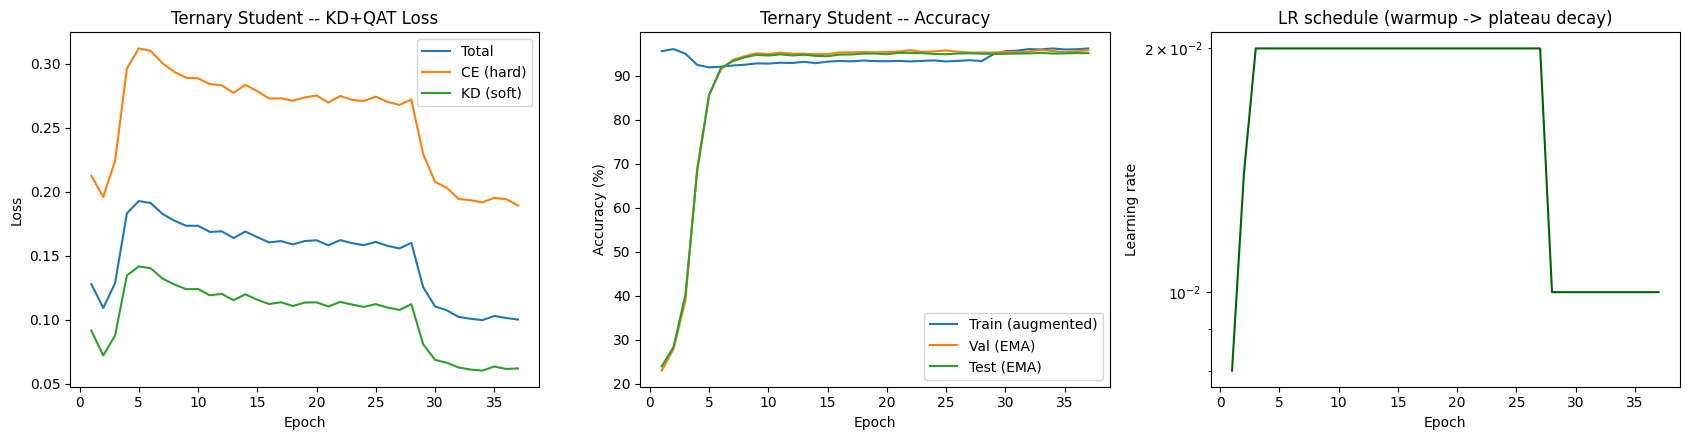

Saved training curves to /content/drive/MyDrive/atdl/student_training_curves.png


In [ ]:
ALPHA = 0.3
TEMPERATURE = 4.0
EPOCHS = 100  # ceiling -- early stopping will likely halt sooner

main_result = train_student(alpha=ALPHA, temperature=TEMPERATURE, epochs=EPOCHS)

## Ablation sweep (required rubric item — run this separately)

The rubric requires "at least one meaningful ablation (T, λ, or Δ)." This sweeps 5 shorter runs (fewer epochs, smaller early-stop patience, since this is for a trend not a final number) across either temperature or alpha, holding the other fixed, and saves `ablation_results.json` + `ablation_plot.png` to `atdl/`.

**This is a separate, substantial amount of additional Colab time** (5 runs x ~40 epochs each) — plan for it as its own session. Run the main training above first, confirm it's good, then come back and run this.


===== Ablation run: alpha=0.3, T=1.0, epochs=40 =====


100%|██████████| 170M/170M [41:40<00:00, 68.2kB/s]


Student latent weights initialized from FP32 baseline (missing=0, unexpected=0)

Early stopping at epoch 9: no val-accuracy improvement (> 0.05 pts) for 8 epochs. Best: 94.84% (raw) at epoch 1.

[alpha=0.3, T=1.0] Best checkpoint: epoch 1, source=raw, val_acc 94.84%
[alpha=0.3, T=1.0] Final test accuracy: 94.38%
[alpha=0.3, T=1.0] Honest clean train accuracy: 99.48%
[alpha=0.3, T=1.0] Honest train/test gap: 5.10 points
Ternary constraint on final checkpoint: 19/19 layers OK (all_ok=True), avg sparsity 0.466

===== Ablation run: alpha=0.3, T=2.0, epochs=40 =====
Student latent weights initialized from FP32 baseline (missing=0, unexpected=0)

Early stopping at epoch 9: no val-accuracy improvement (> 0.05 pts) for 8 epochs. Best: 95.08% (raw) at epoch 1.

[alpha=0.3, T=2.0] Best checkpoint: epoch 1, source=raw, val_acc 95.08%
[alpha=0.3, T=2.0] Final test accuracy: 94.65%
[alpha=0.3, T=2.0] Honest clean train accuracy: 99.54%
[alpha=0.3, T=2.0] Honest train/test gap: 4.89 points
Ternary c

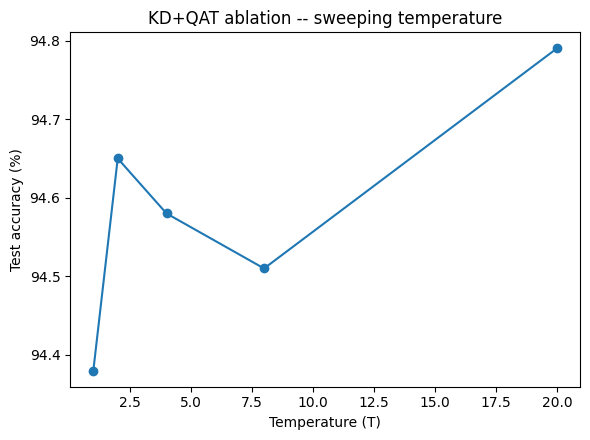

Saved ablation_results.json and ablation_plot.png to /content/drive/MyDrive/atdl


In [13]:
def run_ablation(sweep="temperature", ablation_epochs=40, early_stop_patience=8):
    if sweep == "temperature":
        fixed_alpha = 0.3
        values = [1.0, 2.0, 4.0, 8.0, 20.0]
        configs = [(fixed_alpha, T) for T in values]
        xlabel = "Temperature (T)"
    elif sweep == "alpha":
        fixed_T = 4.0
        values = [0.1, 0.3, 0.5, 0.7, 0.9]
        configs = [(a, fixed_T) for a in values]
        xlabel = "Alpha (hard-label weight)"
    else:
        raise ValueError("sweep must be 'temperature' or 'alpha'")

    all_results = []
    for alpha, T in configs:
        print(f"\n===== Ablation run: alpha={alpha}, T={T}, epochs={ablation_epochs} =====")
        r = train_student(alpha=alpha, temperature=T, epochs=ablation_epochs,
                           warmup_epochs=1, early_stop_patience=early_stop_patience,
                           ckpt_path=os.path.join(DRIVE_DIR, f"ablation_a{alpha}_T{T}.pth"),
                           verbose=False, save_plot=False)
        all_results.append(r)

    with open(os.path.join(DRIVE_DIR, "ablation_results.json"), "w") as f:
        json.dump([{k: v for k, v in r.items() if k != "history"} for r in all_results],
                   f, indent=2)

    x_vals = values
    y_vals = [r["final_test_acc"] for r in all_results]
    plt.figure(figsize=(6, 4.5))
    plt.plot(x_vals, y_vals, marker="o")
    plt.xlabel(xlabel)
    plt.ylabel("Test accuracy (%)")
    plt.title(f"KD+QAT ablation -- sweeping {sweep}")
    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_DIR, "ablation_plot.png"), dpi=150)
    plt.show()
    print(f"Saved ablation_results.json and ablation_plot.png to {DRIVE_DIR}")
    return all_results


# Uncomment ONE of these to actually run the sweep (each takes a while -- do this as its own session):
ablation_results = run_ablation(sweep="temperature")
# ablation_results = run_ablation(sweep="alpha")